In [36]:
# Cell 0 — Project Imports

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

In [37]:
# Cell 1 — 방향 확인용 Asymmetric 3D Volume 생성

# 100 → 몸통
# 300 → Right
# 500 → Anterior
# 700 → Superior

def create_asymmetric_orientation_volume(
    volume_shape_ijk: tuple[int, int, int],           # array axis별 voxel 개수 [I, J, K]
    voxel_spacing_ijk_mm: tuple[float, float, float], # voxel 한 칸의 실제 크기 (mm)
    origin_xyz_mm: tuple[float, float, float],        # origin index (0,0,0)의 physical coordinate
) -> nib.Nifti1Image:
    """방향과 뒤집힘 확인용 asymmetric synthetic NIfTI 생성"""
    
    size_i, size_j, size_k = (
        volume_shape_ijk
    )
    
    # [I, J, K] = [40, 50, 60]
    volume_array: np.ndarray = np.zeros(
        volume_shape_ijk,
        dtype=np.float32,
    )
    
    # Broadcasting 가능한 axis별 coordinate grid 생성
    # ex: i_grid: [I, 1, 1]
    i_grid, j_grid, k_grid = np.ogrid[
        :size_i,
        :size_j,
        :size_k,
    ]
    
    # Volume 중심 좌표 계산
    center_i = (size_i - 1) / 2
    center_j = (size_j - 1) / 2
    center_k = (size_k - 1) / 2
    
    # Body 역할의 타원체 mask 생성: [I, J, K], bool
    body_mask = (
        ((i_grid-center_i) / 16) ** 2
        + ((j_grid-center_j) / 20) ** 2
        + ((k_grid-center_k) / 24) ** 2
        <= 1
    )
    
    
    
    # Body 영역에 intensity 100 배치
    volume_array[
        body_mask
    ] = 100.0
    
    
    # 높은 I 위치에 Right marker 배치:
    # I 증가 → physical X 증가 → Right 방향
    volume_array[
        31:36,
        22:28,
        27:33,
    ] = 300.0


    # 높은 J 위치에 Anterior marker 배치:
    # J 증가 → physical Y 증가 → Anterior 방향
    volume_array[
        18:23,
        39:44,
        27:33,
    ] = 500.0

    # 높은 K 위치에 Superior marker 배치:
    # K 증가 → physical Z 증가 → Superior 방향
    volume_array[
        18:23,
        22:28,
        49:55,
    ] = 700.0
    
    
    
    # Axis rotation이나 flip이 없는 RAS affine matrix:
    affine_ijk_to_xyz: np.ndarray = np.eye(
        4,
        dtype=np.float64,
    )  # [4, 4]
    
    # Array axis별 voxel spacing 배치
    affine_ijk_to_xyz[0, 0] = (
        voxel_spacing_ijk_mm[0] # 2 mm
    )
    affine_ijk_to_xyz[1, 1] = (
        voxel_spacing_ijk_mm[1] # 2 mm
    )
    affine_ijk_to_xyz[2, 2] = (
        voxel_spacing_ijk_mm[2] # 3 mm
    )
    
    # Voxel index (0,0,0)의 physical origin 배치
    affine_ijk_to_xyz[
        :3,
        3,
    ] = np.asarray(
        origin_xyz_mm,
        dtype=np.float64,
    )
    
    # 3D voxel array와 affine을 NIfTI 객체로 결합
    orientation_nifti = nib.Nifti1Image(
        volume_array,
        affine_ijk_to_xyz,
    )

    return orientation_nifti


# 비대칭 synthetic NIfTI 생성
orientation_nifti = (
    create_asymmetric_orientation_volume(
        volume_shape_ijk=(
            40,
            50,
            60,
        ),
        voxel_spacing_ijk_mm=(
            2.0,
            2.0,
            3.0,
        ),
        origin_xyz_mm=(
            -40.0,
            -50.0,
            -90.0,
        ),
    )
)


# NIfTI 객체에서 3D voxel array 추출
orientation_volume: np.ndarray = (
    orientation_nifti.get_fdata(
        dtype=np.float32,
    )
)  # [I=40, J=50, K=60]


# Affine으로부터 array axis의 physical 방향 추출
#
# 현재 예상:
# ('R', 'A', 'S')
orientation_axis_codes = nib.aff2axcodes(
    orientation_nifti.affine
)


# 각 intensity에 해당하는 voxel 개수 계산
#
# intensity 0   → background
# intensity 100 → body
# intensity 300 → Right marker
# intensity 500 → Anterior marker
# intensity 700 → Superior marker
unique_values, voxel_counts = np.unique(
    orientation_volume,
    return_counts=True,
)


print(
    "Volume shape:",
    orientation_volume.shape,
)
print(
    "Voxel spacing:",
    orientation_nifti.header.get_zooms()[:3],
)
print(
    "Axis codes:",
    orientation_axis_codes,
)
print()

print("Intensity distribution:")
for intensity, voxel_count in zip(
    unique_values,
    voxel_counts,
):
    print(
        f"intensity={intensity:5.1f} | "
        f"voxels={voxel_count}"
    )

Volume shape: (40, 50, 60)
Voxel spacing: (np.float32(2.0), np.float32(2.0), np.float32(3.0))
Axis codes: ('R', 'A', 'S')

Intensity distribution:
intensity=  0.0 | voxels=87722
intensity=100.0 | voxels=31768
intensity=300.0 | voxels=180
intensity=500.0 | voxels=150
intensity=700.0 | voxels=180


In [38]:
# Cell 2 — Axial, Coronal과 Sagittal Slice 추출

def extract_three_plane_slices(
    volume_ijk: np.ndarray,                # [I, J, K]
    slice_index_ijk: tuple[int, int, int], # [index_I, index_J, index_K]
) -> tuple[
    np.ndarray,  # Sagittal slice, axis I fixed: [J, K]
    np.ndarray,  # Coronal slice, axis J fixed:  [I, K]
    np.ndarray,  # Axial slice, axis K fixed:    [I, J]
]:
    """RAS volume에서 sagittal, coronal과 axial slice 추출"""
    
    # 세 anatomical plane에서 고정할 index 분리
    index_i, index_j, index_k = (
        slice_index_ijk
    )
    
    # 원본 volume_ijk [I, J, K] 에서
    # Sagittal, Coronal, Axial plane 추출: 특정 X의 위치에서 Y-Z 평면 확인
    sagittal_slice_jk = volume_ijk[
        index_i,
        :,
        :,
    ]
    coronal_slice_ik = volume_ijk[
        :,
        index_j,
        :,
    ]
    axial_slice_ij = volume_ijk[
        :,
        :,
        index_k,
    ]
    
    return (
        sagittal_slice_jk, # [J, K]
        coronal_slice_ik,  # [I, K]
        axial_slice_ij,    # [I, J]
    )
    


# Volume[40, 50, 60] 중앙에 가까운 voxel index 계산:
center_slice_index_ijk: tuple[
    int,
    int,
    int,
] = (
    orientation_volume.shape[0] // 2, # 20
    orientation_volume.shape[1] // 2, # 25
    orientation_volume.shape[2] // 2, # 30
)

# 중앙 index를 기준으로 세 anatomical plane 추출
(
    sagittal_slice_jk, # Sagittal [J=50, K=60]
    coronal_slice_ik,  # Coronal  [I=40, K=60]
    axial_slice_ij,    # Axial    [I=40, J=50]
) = extract_three_plane_slices(
    volume_ijk=orientation_volume,          # Input Volume: [I=40, J=50, K=60]
    slice_index_ijk=center_slice_index_ijk, # Center Index: [I=20, J=25, K=30]
)



# 각 plane에 포함된 intensity 확인
#
# Marker 배치:
# 300 → 높은 I → Right
# 500 → 높은 J → Anterior
# 700 → 높은 K → Superior

# 중앙 sagittal plane:
# I=20이므로 Right marker 300은 통과하지 않음 / Anterior 500과 Superior 700 포함
sagittal_intensities = np.unique(
    sagittal_slice_jk
)


# 중앙 coronal plane:
# J=25이므로 Anterior marker 500은 통과하지 않음 / Right 300과 Superior 700 포함
coronal_intensities = np.unique(
    coronal_slice_ik
)


# 중앙 axial plane:
# K=30이므로 Superior marker 700은 통과하지 않음 / Right 300과 Anterior 500 포함
axial_intensities = np.unique(
    axial_slice_ij
)


print(
    "Volume shape:",
    orientation_volume.shape,
)
print(
    "Center index (IJK):",
    center_slice_index_ijk,
)
print()

print(
    "Sagittal shape [J,K]:",
    sagittal_slice_jk.shape,
)
print(
    "Sagittal intensities:",
    sagittal_intensities,
)
print()

print(
    "Coronal shape [I,K]:",
    coronal_slice_ik.shape,
)
print(
    "Coronal intensities:",
    coronal_intensities,
)
print()

print(
    "Axial shape [I,J]:",
    axial_slice_ij.shape,
)
print(
    "Axial intensities:",
    axial_intensities,
)

Volume shape: (40, 50, 60)
Center index (IJK): (20, 25, 30)

Sagittal shape [J,K]: (50, 60)
Sagittal intensities: [  0. 100. 500. 700.]

Coronal shape [I,K]: (40, 60)
Coronal intensities: [  0. 100. 300. 700.]

Axial shape [I,J]: (40, 50)
Axial intensities: [  0. 100. 300. 500.]


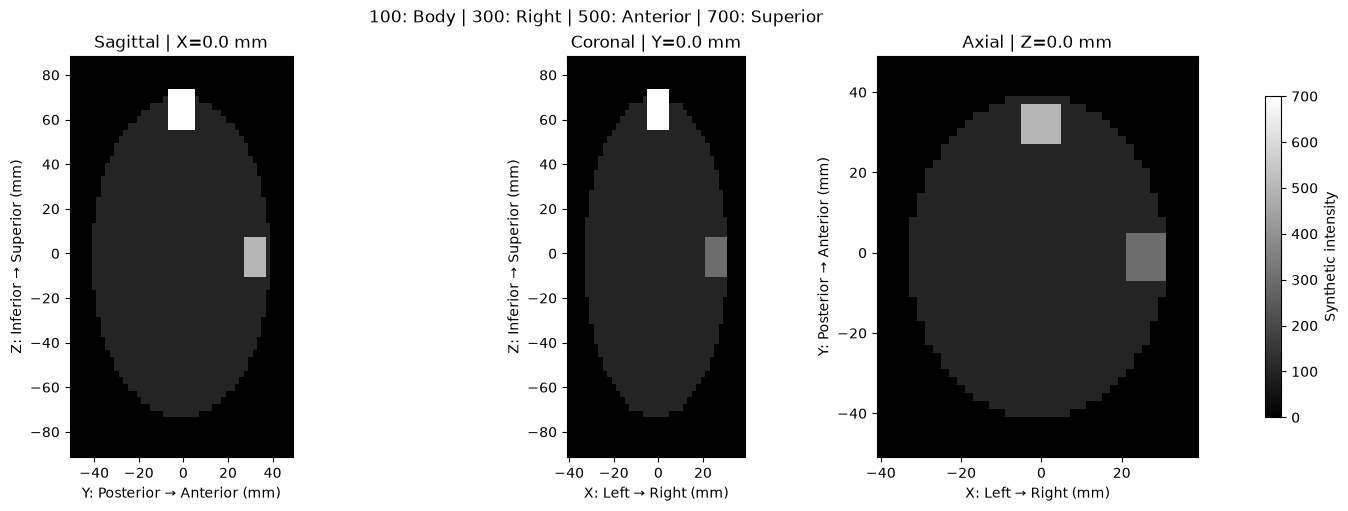

Selected voxel index (IJK): (20, 25, 30)
Selected physical coordinate (XYZ mm): [0. 0. 0.]

Sagittal stored/display shape: (50, 60) → (60, 50)
Coronal stored/display shape:  (40, 60) → (60, 40)
Axial stored/display shape:    (40, 50) → (50, 40)


In [39]:
# Cell 3 — Three-Plane Viewer 시각화

def calculate_axis_edge_extent(
    number_of_voxels: int,
    voxel_spacing_mm: float,
    first_voxel_center_mm: float,
) -> tuple[float, float]:
    """첫 voxel의 왼쪽 끝부터 마지막 voxel의 오른쪽 끝까지 실제 mm 범위를 계산"""

    first_edge_mm = (
        first_voxel_center_mm
        - voxel_spacing_mm / 2
    )

    last_edge_mm = (
        first_voxel_center_mm
        + (
            number_of_voxels
            - 0.5
        )
        * voxel_spacing_mm
    )

    return (
        first_edge_mm,
        last_edge_mm,
    )


def show_three_plane_viewer(
    sagittal_slice_jk: np.ndarray,       # [J, K]
    coronal_slice_ik: np.ndarray,        # [I, K]
    axial_slice_ij: np.ndarray,          # [I, J]
    slice_index_ijk: tuple[int, int, int],
    affine_ijk_to_xyz: np.ndarray,       # [4, 4]
) -> None:
    """Canonical RAS volume의 three-plane viewer 출력"""

    # Slice shape으로 전체 volume의 axis 크기 복원
    size_i = axial_slice_ij.shape[0] 
    size_j = axial_slice_ij.shape[1]
    size_k = sagittal_slice_jk.shape[1]

    # voxel spacing 계산: 
    # [2.0, 2.0, 3.0] mm
    voxel_spacing_ijk_mm = (
        nib.affines.voxel_sizes(
            affine_ijk_to_xyz # Affine transform matrix
        )
    ) # [3]
    spacing_i_mm = float(
        voxel_spacing_ijk_mm[0]
    )
    spacing_j_mm = float(
        voxel_spacing_ijk_mm[1]
    )
    spacing_k_mm = float(
        voxel_spacing_ijk_mm[2]
    )

    # Voxel index (0,0,0)의 physical origin 추출: 
    # [origin_X, origin_Y, origin_Z] mm
    physical_origin_xyz_mm = (
        affine_ijk_to_xyz[ # Affine transform matrix
            :3,
            3,
        ]
    )  # [3]
    origin_x_mm = float(
        physical_origin_xyz_mm[0]
    )
    origin_y_mm = float(
        physical_origin_xyz_mm[1]
    )
    origin_z_mm = float(
        physical_origin_xyz_mm[2]
    )


    # 각 physical axis의 voxel edge 범위 계산
    # X extent: [-41, 39] mm
    # Y extent: [-51, 49] mm
    # Z extent: [-91.5, 88.5] mm
    x_extent_mm = calculate_axis_edge_extent(
        number_of_voxels=size_i,
        voxel_spacing_mm=spacing_i_mm,
        first_voxel_center_mm=origin_x_mm,
    )

    y_extent_mm = calculate_axis_edge_extent(
        number_of_voxels=size_j,
        voxel_spacing_mm=spacing_j_mm,
        first_voxel_center_mm=origin_y_mm,
    )

    z_extent_mm = calculate_axis_edge_extent(
        number_of_voxels=size_k,
        voxel_spacing_mm=spacing_k_mm,
        first_voxel_center_mm=origin_z_mm,
    )

    # 선택한 voxel index를 physical coordinate로 변환:
    # [i,j,k] = [20,25,30] -> [x,y,z] = [0,0,0] mm
    selected_physical_xyz_mm = (
        nib.affines.apply_affine(
            affine_ijk_to_xyz, # Affine transform matrix
            np.asarray(
                slice_index_ijk,
                dtype=np.float64,
            ),
        )
    )  # [3]

    selected_x_mm = float(
        selected_physical_xyz_mm[0]
    )
    selected_y_mm = float(
        selected_physical_xyz_mm[1]
    )
    selected_z_mm = float(
        selected_physical_xyz_mm[2]
    )

    # 세 plane을 가로로 배치할 figure 생성
    figure, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(
            15,
            5,
        ),
        constrained_layout=True,
    )

    # Sagittal slice, Transpose 후 표시
    sagittal_image = axes[0].imshow(
        sagittal_slice_jk.T,
        origin="lower",
        extent=(
            y_extent_mm[0],
            y_extent_mm[1],
            z_extent_mm[0],
            z_extent_mm[1],
        ),
        cmap="gray",
        vmin=0,
        vmax=700,
        interpolation="nearest",
        aspect="equal",
    )
    axes[0].set_title(
        f"Sagittal | X={selected_x_mm:.1f} mm"
    )
    axes[0].set_xlabel(
        "Y: Posterior → Anterior (mm)"
    )
    axes[0].set_ylabel(
        "Z: Inferior → Superior (mm)"
    )

    # Coronal slice, Transpose 후 표시
    axes[1].imshow(
        coronal_slice_ik.T,
        origin="lower",
        extent=(
            x_extent_mm[0],
            x_extent_mm[1],
            z_extent_mm[0],
            z_extent_mm[1],
        ),
        cmap="gray",
        vmin=0,
        vmax=700,
        interpolation="nearest",
        aspect="equal",
    )
    axes[1].set_title(
        f"Coronal | Y={selected_y_mm:.1f} mm"
    )
    axes[1].set_xlabel(
        "X: Left → Right (mm)"
    )
    axes[1].set_ylabel(
        "Z: Inferior → Superior (mm)"
    )

    # Axial slice, Transpose 후 표시
    axes[2].imshow(
        axial_slice_ij.T,
        origin="lower",
        extent=(
            x_extent_mm[0],
            x_extent_mm[1],
            y_extent_mm[0],
            y_extent_mm[1],
        ),
        cmap="gray",
        vmin=0,
        vmax=700,
        interpolation="nearest",
        aspect="equal",
    )

    axes[2].set_title(
        f"Axial | Z={selected_z_mm:.1f} mm"
    )
    axes[2].set_xlabel(
        "X: Left → Right (mm)"
    )
    axes[2].set_ylabel(
        "Y: Posterior → Anterior (mm)"
    )

    # 세 subplot이 공유하는 intensity colorbar 추가
    figure.colorbar(
        sagittal_image,
        ax=axes,
        label="Synthetic intensity",
        shrink=0.8,
    )

    # Marker intensity 의미 표시
    figure.suptitle(
        "100: Body | 300: Right | "
        "500: Anterior | 700: Superior"
    )

    plt.show()


# RAS orientation의 중앙 three-plane viewer 출력
show_three_plane_viewer(
    sagittal_slice_jk=(
        sagittal_slice_jk
    ),  # [J=50, K=60]
    coronal_slice_ik=(
        coronal_slice_ik
    ),  # [I=40, K=60]
    axial_slice_ij=(
        axial_slice_ij
    ),  # [I=40, J=50]
    slice_index_ijk=(
        center_slice_index_ijk
    ),
    affine_ijk_to_xyz=(
        orientation_nifti.affine
    ),  # [4, 4]
)


print(
    "Selected voxel index (IJK):",
    center_slice_index_ijk,
)
print(
    "Selected physical coordinate (XYZ mm):",
    nib.affines.apply_affine(
        orientation_nifti.affine,
        center_slice_index_ijk,
    ),
)
print()

print(
    "Sagittal stored/display shape:",
    sagittal_slice_jk.shape,
    "→",
    sagittal_slice_jk.T.shape,
)
print(
    "Coronal stored/display shape: ",
    coronal_slice_ik.shape,
    "→",
    coronal_slice_ik.T.shape,
)
print(
    "Axial stored/display shape:   ",
    axial_slice_ij.shape,
    "→",
    axial_slice_ij.T.shape,
)

In [40]:
# Cell 4 — Canonical RAS Reorientation 검증

# 원본 NIfTI에서 RAS array와 affine 추출
ras_volume: np.ndarray = (
    orientation_nifti.get_fdata(
        dtype=np.float32,
    )
)  # [I=40, J=50, K=60]
ras_affine: np.ndarray = (
    orientation_nifti.affine
)  # [4, 4]


# 원본 affine에서 현재 array axis 방향 추출
#
# 결과:
#
# [[0, +1],
#  [1, +1],
#  [2, +1]]
#
# 각 row:
# [대응하는 physical axis, 증가 방향]
#
# +1 → 같은 방향
# -1 → 반대 방향
ras_orientation = (
    nib.orientations.io_orientation(
        ras_affine
    )
)  # [3, 2]


# 일부러 만들 target array orientation 정의
#
# L → I axis가 증가하면 Left
# P → J axis가 증가하면 Posterior
# S → K axis가 증가하면 Superior
target_lps_orientation = (
    nib.orientations.axcodes2ornt(
        (
            "L",
            "P",
            "S",
        )
    )
)  # [3, 2]


# 현재 RAS array를 LPS axis 방향으로 바꾸기 위한
# orientation transform 계산
#
# 결과:
#
# [[0, -1],
#  [1, -1],
#  [2, +1]]
#
# Axis 0 → flip
# Axis 1 → flip
# Axis 2 → 유지
ras_to_lps_transform = (
    nib.orientations.ornt_transform(
        ras_orientation,
        target_lps_orientation,
    )
)  # [3, 2]


# RAS array에 orientation transform 적용
#
# 원본 shape:
# [40,50,60]
#
# I와 J axis를 뒤집지만 axis permutation은 없으므로
# 결과 shape도 동일:
# [40,50,60]
lps_volume: np.ndarray = (
    nib.orientations.apply_orientation(
        ras_volume,
        ras_to_lps_transform,
    )
)  # [I=40, J=50, K=60]


# 새 LPS voxel index를 원래 RAS voxel index로 연결하는
# voxel-to-voxel affine 계산
#
# 예:
#
# RAS index [33,25,30]
#             ↑
# LPS index [6,24,30]
#
# I축:
# 39 - 33 = 6
#
# J축:
# 49 - 25 = 24
lps_index_to_ras_index_affine = (
    nib.orientations.inv_ornt_aff(
        ras_to_lps_transform,
        ras_volume.shape,
    )
)  # [4, 4]


# LPS array용 새 affine 계산
#
# 변환 흐름:
#
# LPS voxel index
#       ↓ lps_index_to_ras_index_affine
# RAS voxel index
#       ↓ ras_affine
# Physical XYZ
#
# 행렬 결합:
#
# lps_affine
# = ras_affine
# @ lps_index_to_ras_index_affine
lps_affine: np.ndarray = (
    ras_affine
    @ lps_index_to_ras_index_affine
)  # [4, 4]


# 뒤집힌 array와 갱신된 affine을 결합
#
# Array orientation은 LPS지만
# 동일한 환자 physical anatomy 표현
lps_nifti = nib.Nifti1Image(
    lps_volume,
    lps_affine,
)


# 새 affine에서 axis codes 확인
#
# 예상 결과:
# ('L', 'P', 'S')
lps_axis_codes = nib.aff2axcodes(
    lps_nifti.affine
)


# LPS-oriented NIfTI를 canonical RAS로 변환
#
# 내부 작업:
# 1. Axis 방향 확인
# 2. 필요한 axis permutation과 flip 적용
# 3. Affine 동시 갱신
#
# 단순 reorientation이므로 interpolation 없음
canonical_ras_nifti = (
    nib.as_closest_canonical(
        lps_nifti
    )
)


# Canonical RAS array와 affine 추출
canonical_ras_volume: np.ndarray = (
    canonical_ras_nifti.get_fdata(
        dtype=np.float32,
    )
)  # [I=40, J=50, K=60]

canonical_ras_affine: np.ndarray = (
    canonical_ras_nifti.affine
)  # [4, 4]

canonical_axis_codes = nib.aff2axcodes(
    canonical_ras_affine
)


# Right marker 내부의 원본 RAS voxel 선택
#
# Cell 1의 Right marker 범위:
#
# I: 31:36
# J: 22:28
# K: 27:33
#
# 선택 voxel:
# [33,25,30]
#
# Intensity 예상:
# 300
ras_landmark_index_ijk = np.asarray(
    [
        33.0,
        25.0,
        30.0,
    ],
    dtype=np.float64,
)  # [3]


# RAS index를 대응하는 LPS index로 변환
#
# 현재 보유한 행렬:
# LPS index → RAS index
#
# 반대 방향이 필요하므로 inverse 사용:
# RAS index → LPS index
ras_index_to_lps_index_affine = (
    np.linalg.inv(
        lps_index_to_ras_index_affine
    )
)  # [4, 4]

lps_landmark_index_ijk = (
    nib.affines.apply_affine(
        ras_index_to_lps_index_affine,
        ras_landmark_index_ijk,
    )
)  # [3]


# Floating-point 좌표를 실제 array indexing용 정수로 변환
ras_landmark_discrete_index = tuple(
    np.rint(
        ras_landmark_index_ijk
    ).astype(
        np.int64
    )
)

lps_landmark_discrete_index = tuple(
    np.rint(
        lps_landmark_index_ijk
    ).astype(
        np.int64
    )
)


# 서로 다른 array index에서 landmark intensity 확인
#
# RAS index:
# [33,25,30]
#
# LPS index:
# [6,24,30]
#
# 두 위치 모두 intensity 300 예상
ras_landmark_value = ras_volume[
    ras_landmark_discrete_index
].item()

lps_landmark_value = lps_volume[
    lps_landmark_discrete_index
].item()


# 각 array index를 physical coordinate로 변환
#
# Array index는 서로 다르지만
# physical coordinate는 동일해야 함
ras_landmark_physical_xyz_mm = (
    nib.affines.apply_affine(
        ras_affine,
        ras_landmark_index_ijk,
    )
)  # [3]

lps_landmark_physical_xyz_mm = (
    nib.affines.apply_affine(
        lps_affine,
        lps_landmark_index_ijk,
    )
)  # [3]


# Physical landmark 위치 보존 여부 확인
landmark_physical_position_preserved = (
    np.allclose(
        ras_landmark_physical_xyz_mm,
        lps_landmark_physical_xyz_mm,
    )
)


# Canonical 변환 후 원본 RAS array 복원 여부 확인
canonical_array_matches_original = (
    np.array_equal(
        canonical_ras_volume,
        ras_volume,
    )
)


# Canonical 변환 후 원본 RAS affine 복원 여부 확인
canonical_affine_matches_original = (
    np.allclose(
        canonical_ras_affine,
        ras_affine,
    )
)


# Canonical array와 원본 array의 최대 voxel 차이
maximum_voxel_difference = np.max(
    np.abs(
        canonical_ras_volume
        - ras_volume
    )
).item()


print(
    "Original axis codes:",
    nib.aff2axcodes(
        ras_affine
    ),
)
print(
    "Changed axis codes: ",
    lps_axis_codes,
)
print(
    "Canonical axis codes:",
    canonical_axis_codes,
)
print()

print("RAS-to-LPS transform:")
print(ras_to_lps_transform)
print()

print("LPS affine:")
print(lps_affine)
print()

print(
    "RAS landmark index:",
    ras_landmark_index_ijk,
)
print(
    "LPS landmark index:",
    lps_landmark_index_ijk,
)
print(
    "RAS/LPS landmark values:",
    ras_landmark_value,
    lps_landmark_value,
)
print()

print(
    "RAS physical coordinate:",
    ras_landmark_physical_xyz_mm,
)
print(
    "LPS physical coordinate:",
    lps_landmark_physical_xyz_mm,
)
print(
    "Physical position preserved:",
    landmark_physical_position_preserved,
)
print()

print(
    "Canonical array matches original:",
    canonical_array_matches_original,
)
print(
    "Canonical affine matches original:",
    canonical_affine_matches_original,
)
print(
    "Maximum voxel difference:",
    maximum_voxel_difference,
)

Original axis codes: ('R', 'A', 'S')
Changed axis codes:  ('L', 'P', 'S')
Canonical axis codes: ('R', 'A', 'S')

RAS-to-LPS transform:
[[ 0. -1.]
 [ 1. -1.]
 [ 2.  1.]]

LPS affine:
[[ -2.   0.   0.  38.]
 [  0.  -2.   0.  48.]
 [  0.   0.   3. -90.]
 [  0.   0.   0.   1.]]

RAS landmark index: [33. 25. 30.]
LPS landmark index: [ 6. 24. 30.]
RAS/LPS landmark values: 300.0 300.0

RAS physical coordinate: [26.  0.  0.]
LPS physical coordinate: [26.  0.  0.]
Physical position preserved: True

Canonical array matches original: True
Canonical affine matches original: True
Maximum voxel difference: 0.0
